<a href="https://colab.research.google.com/github/eojin22/ESAA/blob/main/%ED%94%8C%EC%A0%9D3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#회귀를 이용한 영화 관객수 예측

##1. 데이터 불러오기 및 확인

In [1]:
from google.colab import files
uploaded = files.upload()

Saving movies_test (1).csv to movies_test (1) (1).csv
Saving submission (1).csv to submission (1) (1).csv
Saving movies_train (1).csv to movies_train (1) (1).csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
train = pd.read_csv('movies_train (1).csv')
test = pd.read_csv('movies_test (1).csv')
submission = pd.read_csv('submission (1).csv')

In [4]:
print(train.shape)
print(test.shape)
print(submission.shape)

(600, 12)
(243, 11)
(243, 2)


In [5]:
train.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
0,개들의 전쟁,롯데엔터테인먼트,액션,2012-11-22,96,청소년 관람불가,조병옥,NaN,0,91,2,23398
1,내부자들,(주)쇼박스,느와르,2015-11-19,130,청소년 관람불가,우민호,1161602.50,2,387,3,7072501
2,은밀하게 위대하게,(주)쇼박스,액션,2013-06-05,123,15세 관람가,장철수,220775.25,4,343,4,6959083
3,나는 공무원이다,(주)NEW,코미디,2012-07-12,101,전체 관람가,구자홍,23894.00,2,20,6,217866
4,불량남녀,쇼박스(주)미디어플렉스,코미디,2010-11-04,108,15세 관람가,신근호,1.00,1,251,2,483387


In [6]:
test.head()

,title,distributor,genre,release_time,time,screening_rat,director,dir_prev_bfnum,dir_prev_num,num_staff,num_actor
0,용서는 없다,시네마서비스,느와르,2010-01-07,125,청소년 관람불가,김형준,3.005290e+05,2,304,3
1,아빠가 여자를 좋아해,(주)쇼박스,멜로/로맨스,2010-01-14,113,12세 관람가,이광재,3.427002e+05,4,275,3
2,하모니,CJ 엔터테인먼트,드라마,2010-01-28,115,12세 관람가,강대규,4.206611e+06,3,419,7
3,의형제,(주)쇼박스,액션,2010-02-04,116,15세 관람가,장훈,6.913420e+05,2,408,2
4,평행 이론,CJ 엔터테인먼트,공포,2010-02-18,110,15세 관람가,권호영,3.173800e+04,1,380,1


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           600 non-null    object 
 1   distributor     600 non-null    object 
 2   genre           600 non-null    object 
 3   release_time    600 non-null    object 
 4   time            600 non-null    int64  
 5   screening_rat   600 non-null    object 
 6   director        600 non-null    object 
 7   dir_prev_bfnum  270 non-null    float64
 8   dir_prev_num    600 non-null    int64  
 9   num_staff       600 non-null    int64  
 10  num_actor       600 non-null    int64  
 11  box_off_num     600 non-null    int64  
dtypes: float64(1), int64(5), object(6)
memory usage: 56.4+ KB


In [8]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 243 entries, 0 to 242
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   title           243 non-null    object 
 1   distributor     243 non-null    object 
 2   genre           243 non-null    object 
 3   release_time    243 non-null    object 
 4   time            243 non-null    int64  
 5   screening_rat   243 non-null    object 
 6   director        243 non-null    object 
 7   dir_prev_bfnum  107 non-null    float64
 8   dir_prev_num    243 non-null    int64  
 9   num_staff       243 non-null    int64  
 10  num_actor       243 non-null    int64  
dtypes: float64(1), int64(4), object(6)
memory usage: 21.0+ KB


In [9]:
train.describe()

,time,dir_prev_bfnum,dir_prev_num,num_staff,num_actor,box_off_num
count,600.000000,2.700000e+02,600.000000,600.000000,600.000000,6.000000e+02
mean,100.863333,1.050443e+06,0.876667,151.118333,3.706667,7.081818e+05
std,18.097528,1.791408e+06,1.183409,165.654671,2.446889,1.828006e+06
min,45.000000,1.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
25%,89.000000,2.038000e+04,0.000000,17.000000,2.000000,1.297250e+03
50%,100.000000,4.784236e+05,0.000000,82.500000,3.000000,1.259100e+04
75%,114.000000,1.286569e+06,2.000000,264.000000,4.000000,4.798868e+05
max,180.000000,1.761531e+07,5.000000,869.000000,25.000000,1.426277e+07


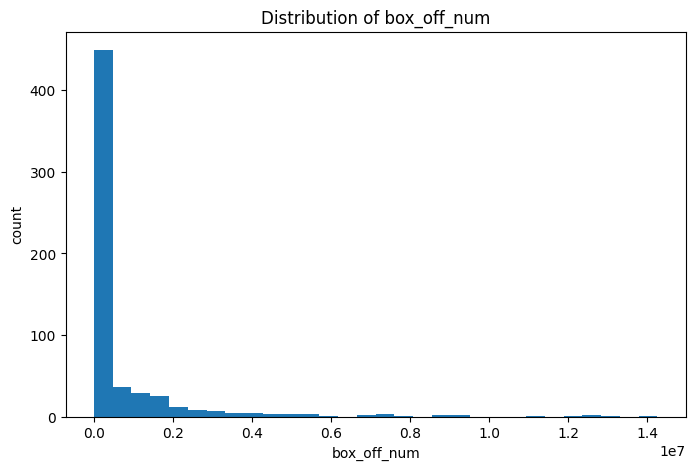

In [10]:
plt.figure(figsize=(8, 5))
plt.hist(train['box_off_num'], bins=30)
plt.title('Distribution of box_off_num')
plt.xlabel('box_off_num')
plt.ylabel('count')
plt.show()

곽객수 데이터가 한쪽으로 크게 치우쳐져있다.

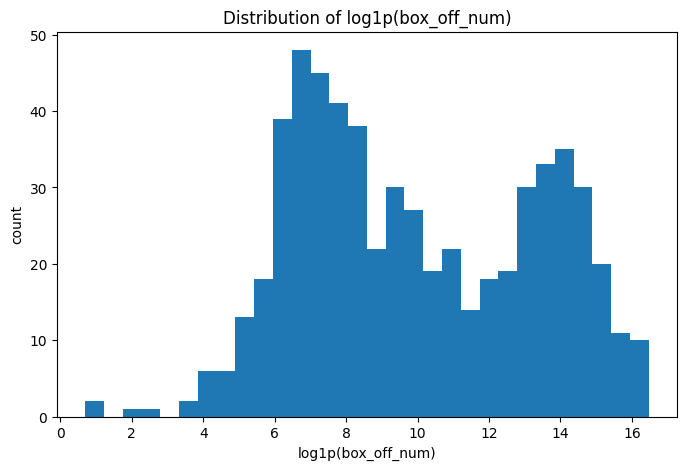

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(train['box_off_num']), bins=30)
plt.title('Distribution of log1p(box_off_num)')
plt.xlabel('log1p(box_off_num)')
plt.ylabel('count')
plt.show()

관객 수 데이터는 일부 흥행작에 의해 오른쪽으로 치우친 분포를 보였기 때문에 로그 변환을 적용하여 분포를 완화하였다.

##2. 전처리

### (1) 결측치 확인 및 처리

In [12]:
train.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,330
dir_prev_num,0
num_staff,0


In [13]:
test.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,136
dir_prev_num,0
num_staff,0


결측치 확인 결과, 감독의 이전 작품 평균 관객 수를 의미하는 dir_prev_bfnum 변수에서 결측치가 발견되었다. 이는 이전 작품 정보가 없는 감독의 경우로 해석할 수 있으므로 전처리 과정에서 0으로 처리하면 된다.

In [14]:
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
test['dir_prev_bfnum'] = test['dir_prev_bfnum'].fillna(0)

In [15]:
train.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,0
dir_prev_num,0
num_staff,0


In [16]:
test.isnull().sum()

,0
title,0
distributor,0
genre,0
release_time,0
time,0
screening_rat,0
director,0
dir_prev_bfnum,0
dir_prev_num,0
num_staff,0


결측치를 0으로 대체하여 결측치가 사라진 것을 확인할 수 있다.

In [17]:
import numpy as np
import pandas as pd

# 날짜 가공 및 연도/월 피처 생성
train['release_time'] = pd.to_datetime(train['release_time'])
test['release_time'] = pd.to_datetime(test['release_time'])

train['release_year'] = train['release_time'].dt.year
test['release_year'] = test['release_time'].dt.year
train['release_month'] = train['release_time'].dt.month
test['release_month'] = test['release_time'].dt.month

# 영화 관객 성수기 피처 (7, 8, 12, 1월은 1, 나머지는 0)
train['is_season'] = train['release_month'].apply(lambda x: 1 if x in [7, 8, 12, 1] else 0)
test['is_season'] = test['release_month'].apply(lambda x: 1 if x in [7, 8, 12, 1] else 0)

# 타겟값(정답지) 로그 변환 - 명확하게 하나의 변수로 고정
y_final_log = np.log1p(train['box_off_num'])

# 5대 메이저 배급사 파생변수
major_distributors = ['CJE&M Movie', '롯데엔터테인먼트', '쇼박스', 'NEW', '메가박스']
train['is_major'] = train['distributor'].apply(lambda x: 1 if x in major_distributors else 0)
test['is_major'] = test['distributor'].apply(lambda x: 1 if x in major_distributors else 0)

# 수치형 피처 결측치 채우기 및 로그 변환
train['dir_prev_bfnum'] = train['dir_prev_bfnum'].fillna(0)
test['dir_prev_bfnum'] = test['dir_prev_bfnum'].fillna(0)

train['num_staff_log'] = np.log1p(train['num_staff'])
test['num_staff_log'] = np.log1p(test['num_staff'])
train['dir_prev_bfnum_log'] = np.log1p(train['dir_prev_bfnum'])
test['dir_prev_bfnum_log'] = np.log1p(test['dir_prev_bfnum'])

# train과 test 모두 수치형 원본 스태프 수 기준으로 동기화
train['staff_per_actor'] = train['num_staff'] / (train['num_actor'] + 1)
test['staff_per_actor'] = test['num_staff'] / (test['num_actor'] + 1)

# 불필요 원본 컬럼 및 중복 라벨 인코딩 변수 드롭
drop_cols = ['box_off_num', 'title', 'release_time', 'distributor', 'director', 'num_staff', 'dir_prev_bfnum', 'genre_le', 'screening_rat_le']
X_clean = train.drop(columns=drop_cols, errors='ignore')
X_test_clean = test.drop(columns=drop_cols, errors='ignore')

# 원-핫 인코딩 안전 수행
oh_cols = ['genre', 'screening_rat']
full_df = pd.concat([X_clean, X_test_clean], axis=0)
full_encoded_df = pd.get_dummies(full_df, columns=oh_cols, drop_first=True)

# 최종 학습/테스트 데이터셋 분리
X_final_encoded = full_encoded_df.iloc[:len(X_clean), :]
test_final_encoded = full_encoded_df.iloc[len(X_clean):, :]

print("학습 차원: {} | 테스트 차원: {}".format(X_final_encoded.shape, test_final_encoded.shape))

학습 차원: (600, 24) | 테스트 차원: (243, 24)


###`release_time`에서 연도, 월, 일 파생변수 생성

In [18]:
#release_time 날짜형으로 변환
train['release_time'] = pd.to_datetime(train['release_time'])
test['release_time'] = pd.to_datetime(test['release_time'])

In [19]:
#연도, 월, 일 파생변수 생성
train['release_year'] = train['release_time'].dt.year
train['release_month'] = train['release_time'].dt.month
train['release_day'] = train['release_time'].dt.day

test['release_year'] = test['release_time'].dt.year
test['release_month'] = test['release_time'].dt.month
test['release_day'] = test['release_time'].dt.day

In [20]:
train[['release_time', 'release_year', 'release_month', 'release_day']].head()

,release_time,release_year,release_month,release_day
0,2012-11-22,2012,11,22
1,2015-11-19,2015,11,19
2,2013-06-05,2013,6,5
3,2012-07-12,2012,7,12
4,2010-11-04,2010,11,4


In [21]:
test[['release_time', 'release_year', 'release_month', 'release_day']].head()

,release_time,release_year,release_month,release_day
0,2010-01-07,2010,1,7
1,2010-01-14,2010,1,14
2,2010-01-28,2010,1,28
3,2010-02-04,2010,2,4
4,2010-02-18,2010,2,18


`release_time`은 문자열 형태의 날짜 데이터였기 때문에 회귀 모델에 바로 사용하기 어렵다. 따라서 날짜형으로 변환한 뒤, 개봉 연도, 개봉 월, 개봉 일 변수를 새롭게 생성하였다. 영화의 개봉 시기는 방학, 명절, 성수기 등과 관련되어 관객 수에 영향을 줄 수 있으므로 파생변수로 활용하였다.

## realse time 제거

In [22]:
#train = train.drop(['release_year'], axis=1)
#test = test.drop(['release_year'], axis=1)

###(2) 배급사명 통일

In [23]:
print(sorted(train['distributor'].unique()))
print(sorted(test['distributor'].unique()))

['(주) 브릿지웍스', '(주) 액티버스엔터테인먼트', '(주) 영화사조제', '(주) 영화제작전원사', '(주) 케이알씨지', '(주)JK필름', '(주)NEW', '(주)고앤고 필름', '(주)노버스엔터테인먼트', '(주)대명문화공장', '(주)더픽쳐스', '(주)두타연', '(주)드림팩트엔터테인먼트', '(주)랠리버튼', '(주)레인보우 팩토리', '(주)로드하우스', '(주)리틀빅픽처스', '(주)마운틴픽쳐스', '(주)마인스 엔터테인먼트', '(주)마인스엔터테인먼트', '(주)미디어데이', '(주)쇼박스', '(주)스마일이엔티', '(주)스톰픽쳐스코리아', '(주)시네마달', '(주)씨엠닉스', '(주)아우라픽처스', '(주)아이필름코퍼레이션', '(주)에이원 엔터테인먼트', '(주)엣나인필름', '(주)예지림 엔터테인먼트', '(주)온비즈넷', '(주)유비네트워크', '(주)유비콘텐츠', '(주)이스트스카이필름', '(주)콘텐츠 윙', '(주)키노아이', '(주)팝 파트너스', '(주)팝엔터테인먼트', '(주)패뷸러스', '(주)패스파인더씨앤씨', '(주)프레인글로벌', '(주)피터팬픽쳐스', '(주)휘엔터테인먼트', 'BoXoo 엔터테인먼트', 'CGV 무비꼴라쥬', 'CGV 아트하우스', 'CGV아트하우스', 'CJ CGV', 'CJ E&M Pictures', 'CJ E&M 영화부문', 'CJ 엔터테인먼트', 'KBS미디어(주)', 'KT', 'KT&G 상상마당', 'M2픽처스', 'NEW', 'OAL(올)', 'SBS콘텐츠허브', 'SK텔레콤(주)', 'SK플래닛', 'THE 픽쳐스', 'tvN', 'ysfilm', '건시네마', '고구마공작소', '골든타이드픽처스', '김기덕 필름', '나우콘텐츠', '나이너스엔터테인먼트(주)', '노바엔터테인먼트', '더 피플', '더픽쳐스/(주)마운틴픽쳐스', '동국대학교 충무로영상제작센터', '두 엔터테인먼트', '드림로드', '드림팩트 엔터테인먼트', '디 씨드', '디마엔터테인먼트', '롤러코스터 

In [24]:
train['distributor'].value_counts()

,count
distributor,
CJ 엔터테인먼트,54
롯데엔터테인먼트,52
(주)NEW,30
(주)마운틴픽쳐스,29
(주)쇼박스,26
...,...
영화사 廊,1
크리에이티브컴즈(주),1
ysfilm,1


In [25]:
test['distributor'].value_counts()

,count
distributor,
CJ 엔터테인먼트,31
롯데엔터테인먼트,24
(주)마운틴픽쳐스,14
(주)쇼박스,12
골든타이드픽처스,12
...,...
(주)스톰픽쳐스코리아,1
(주)다세포클럽,1
디씨드,1


동일 배급사에 대해 같은 키워드가 들어가는데 표현이 다를 경우 배급사명을 통일한다.

step1) 키워드 기반 일괄 통합 함수 정의

In [30]:
import pandas as pd

def simplify_distributor(name):
    if pd.isna(name):
        return name

    # 문자열 변환 및 앞뒤 공백 제거
    name = str(name).strip()

    # 핵심 키워드가 포함되어 있으면 대표명으로 통일
    if "CGV" in name or "무비꼴라쥬" in name:
        return "CGV아트하우스"
    elif "쇼박스" in name:
        return "쇼박스"
    elif "싸이더스" in name:
        return "싸이더스FNH"
    elif "NEW" in name:
        return "NEW"
    elif "리틀빅" in name:
        return "리틀빅픽처스"
    elif "시네마달" in name or "시네마 달" in name:
        return "시네마달"
    elif "스폰지" in name:
        return "스폰지이엔티"
    elif "롯데" in name:
        return "롯데엔터테인먼트"
    elif "SK" in name:
        return "SK"
    elif "마운틴" in name:
        return "마운틴픽처스"
    elif "드림팩트" in name:
        return "드림팩트엔터테인먼트"
    elif "에이원" in name:
        return "에이원엔터테인먼트"
    else:
        return name

step2) 글자가 아예 다른 계열사 및 특수 케이스 딕셔너리 정의
- 키워드 포함 검사로 걸러내지 못하는 대상을 최종 매핑

In [31]:
import pandas as pd

# 정확한 이름 매핑
dist_map = {
    # CJ 계열 통합
    'CJ 엔터테인먼트': 'CJ ENM',
    'CJ E&M 영화부문': 'CJ ENM',
    'CJ E&M Pictures': 'CJ ENM',

    # 합병 및 계열사 관계
    '메가박스(주)플러스엠': '메가박스',
    '씨너스엔터테인먼트(주)': '메가박스',
    '콘텐츠판다': 'NEW',

    # 조이앤시네마 통합
    '조이앤컨텐츠그룹': '조이앤시네마',
    '스크린조이': '조이앤시네마',
    '(주) 케이알씨지': '조이앤시네마',

    # 기타
    '사람과 사람들': '키노아이DMC',
    '(주)키노아이': '키노아이DMC',
    '(주)JK필름': '롯데엔터테인먼트',
    '(주)이스트스카이필름': '롯데엔터테인먼트'
}


step3) train 및 test 데이터셋에 적용

In [32]:
for df in [train, test]:
    # 키워드 중심
    df['distributor'] = df['distributor'].apply(simplify_distributor)

    # 계열사 및 잔여
    df['distributor'] = df['distributor'].replace(dist_map)

step4) 결과 검증 및 확인

In [33]:
print("==== Train 데이터 배급사====")
print(train['distributor'].value_counts().head(10))

print("\n==== Test 데이터 배급사====")
print(test['distributor'].value_counts().head(10))

==== Train 데이터 배급사====
distributor
CJ ENM      59
롯데엔터테인먼트    54
NEW         39
마운틴픽처스      33
쇼박스         28
인디스토리       26
시네마달        18
조이앤시네마      18
CGV아트하우스    15
골든타이드픽처스    15
Name: count, dtype: int64

==== Test 데이터 배급사====
distributor
CJ ENM       32
롯데엔터테인먼트     25
마운틴픽처스       16
쇼박스          14
골든타이드픽처스     12
인디스토리        11
NEW          10
시네마달          7
KT&G 상상마당     6
CGV아트하우스      5
Name: count, dtype: int64


### (3) 이상치 로그변환

In [34]:
#이상치 확인

Q1 = train['box_off_num'].quantile(0.25)
Q3 = train['box_off_num'].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5*IQR
upper = Q3 + 1.5*IQR

outliers = train[(train['box_off_num'] < lower) | (train['box_off_num'] > upper)]
out_num = outliers['box_off_num']

print(f'관객수 이상치 개수:{len(outliers)}')

관객수 이상치 개수:97


In [35]:
#관객수 이상치 로그변환

train['box_off_num_log'] = np.log1p(train['box_off_num'])

### (4) 피처 인코딩

###1. 라벨 인코딩
- 배급사, 장르, 관람등급, 감독 이름 -> 라벨 인코딩

In [38]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

cols = ['distributor', 'genre', 'screening_rat', 'director']

label_encoders = {}

for col in cols:
    le = LabelEncoder()

    # train + test를 합쳐서 fit
    combined = pd.concat([train[col], test[col]]).astype(str)
    le.fit(combined)

    # train, test 각각 transform
    train[col + '_le'] = le.transform(train[col].astype(str))
    test[col + '_le'] = le.transform(test[col].astype(str))

    # encoder 저장
    label_encoders[col] = le

### 2. one-hot encoding


In [40]:
# X, y 분리
X = train.drop(['box_off_num', 'title', 'box_off_num_log'], axis=1)
y = train['box_off_num']

# '기타'를 NaN으로 대체
X = X.replace('기타', np.nan)
test = test.replace('기타', np.nan)

# train과 test를 합치기
# (원-핫 인코딩 후 컬럼을 동일하게 맞추기 위해)
full = pd.concat([X, test], axis=0)

# 원-핫 인코딩
full_encoded = pd.get_dummies(full, drop_first=True)

# 다시 train/test로 분리
X_encoded = full_encoded.iloc[:len(X), :]
test_encoded = full_encoded.iloc[len(X):, :]

print("X_encoded:", X_encoded.shape)
print("test_encoded:", test_encoded.shape)

X_encoded: (600, 1059)
test_encoded: (243, 1059)


3. 회귀 적용

In [ ]:
! pip install catboost

In [ ]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from catboost import CatBoostRegressor

# 변수명 혼선 방지를 위한 명시적 재선언
X_train = X_final_encoded.copy()
X_test = test_final_encoded.copy()

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# 5-Fold 구조 정의
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# [규제 강화 세팅] 데이터가 적으므로 깊이를 대폭 줄여 과적합을 방어
rf_model = RandomForestRegressor(n_estimators=500, max_depth=6, min_samples_leaf=5, random_state=42, n_jobs=-1)
xgb_model = XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=3, subsample=0.7, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=1.5, random_state=42, n_jobs=-1)
lgbm_model = LGBMRegressor(n_estimators=500, learning_rate=0.02, max_depth=3, subsample=0.7, colsample_bytree=0.7, reg_alpha=0.5, reg_lambda=1.5, random_state=42, n_jobs=-1, verbose=-1)
cb_model = CatBoostRegressor(iterations=600, learning_rate=0.02, depth=3, l2_leaf_reg=5, random_state=42, verbose=0)

# OOF 및 예측 배열 초기화
rf_oof, xgb_oof, lgbm_oof, cb_oof = [np.zeros(len(X_train)) for _ in range(4)]
rf_test, xgb_test, lgbm_test, cb_test = [np.zeros(len(X_test)) for _ in range(4)]

print("\n 최적화 5-Fold 교차 검증 및 로그 스케일 학습\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train, y_final_log)):
    X_tr, y_tr = X_train.iloc[train_idx], y_final_log.iloc[train_idx]
    X_va, y_va = X_train.iloc[val_idx], y_final_log.iloc[val_idx]

    rf_model.fit(X_tr, y_tr)
    rf_oof[val_idx] = rf_model.predict(X_va)
    rf_test += rf_model.predict(X_test) / kf.n_splits

    xgb_model.fit(X_tr, y_tr)
    xgb_oof[val_idx] = xgb_model.predict(X_va)
    xgb_test += xgb_model.predict(X_test) / kf.n_splits

    lgbm_model.fit(X_tr, y_tr)
    lgbm_oof[val_idx] = lgbm_model.predict(X_va)
    lgbm_test += lgbm_model.predict(X_test) / kf.n_splits

    cb_model.fit(X_tr, y_tr)
    cb_oof[val_idx] = cb_model.predict(X_va)
    cb_test += cb_model.predict(X_test) / kf.n_splits

y_true_raw = np.expm1(y_final_log)
print("개별 모델 복원 후 기본 RMSE 확인")
print("RandomForest RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(rf_oof))))
print("XGBoost RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(xgb_oof))))
print("LightGBM RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(lgbm_oof))))
print("CatBoost RMSE : {:.2f}".format(rmse(y_true_raw, np.expm1(cb_oof))))

In [ ]:
# 2차 스태킹 앙상블
#Stacking_X_train = np.column_stack((rf_oof, xgb_oof, lgbm_oof, cb_oof))
#Stacking_X_test = np.column_stack((rf_test, xgb_test, lgbm_test, cb_test))

#meta_model = Ridge(alpha=10.0)
#meta_model.fit(Stacking_X_train, y_train_log)

#final_oof_log = meta_model.predict(Stacking_X_train)
#final_test_log = meta_model.predict(Stacking_X_test)

#final_rmse = rmse(y_true_raw, np.expm1(final_oof_log))
#print("최종 개선 Stacking 앙상블 종합 복원 RMSE: {:.2f}".format(final_rmse))

In [ ]:
w_rf = 0.05
w_xgb = 0.35
w_lgbm = 0.10
w_cb = 0.50

final_oof_blend = (w_rf * rf_oof) + (w_xgb * xgb_oof) + (w_lgbm * lgbm_oof) + (w_cb * cb_oof)
final_test_blend = (w_rf * rf_test) + (w_xgb * xgb_test) + (w_lgbm * lgbm_test) + (w_cb * cb_test)

final_rmse = rmse(y_true_raw, np.expm1(final_oof_blend))
print("\n 최종 Stacking 앙상블 종합 복원 RMSE: {:.2f}".format(final_rmse))

final_predictions = np.expm1(final_test_blend)
final_predictions = np.where(final_predictions < 0, 0, final_predictions)
final_predictions = np.round(final_predictions)

submission['box_off_num'] = final_predictions
submission.to_csv('submission_3.csv', index=False)